In [1]:
# ✅ Create the dataset split files properly
import os

os.makedirs("/content/WildDeepfake/videos", exist_ok=True)

# Create train.txt and val.txt (as plain text files)
with open("/content/train.txt", "w") as f:
    f.write("""/content/WildDeepfake/videos/fake_video_001 1
/content/WildDeepfake/videos/fake_video_002 1
/content/WildDeepfake/videos/real_video_001 0
/content/WildDeepfake/videos/real_video_002 0
""")

with open("/content/val.txt", "w") as f:
    f.write("""/content/WildDeepfake/videos/fake_video_003 1
/content/WildDeepfake/videos/real_video_003 0
""")

print("✅ train.txt and val.txt created successfully!")


✅ train.txt and val.txt created successfully!


In [11]:
# Run in one cell (Colab)
!pip install --upgrade pip
!pip install webdataset huggingface-hub opencv-python-headless pillow tqdm
# optional if you want facenet later:
!pip install facenet-pytorch decord


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [webdataset]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 60.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 13.1 MB/s  0:00:35
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 28.4 MB/s  0:00:14
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 32.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 35.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 20.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 11.6 MB/s  0:00:35
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
#!/usr/bin/env python3
"""
build_balanced_subset_fast.py

Faster balanced subset builder for WildDeepfake WebDataset shards.
Strategy:
 - get list of shard paths from HF
 - shuffle shard list
 - open one shard URL at a time and stream only that shard
 - extract faces and save crops, increment counts
 - stop immediately when targets are reached

Usage:
  python build_balanced_subset_fast.py

Dependencies:
  pip install webdataset huggingface-hub opencv-python-headless pillow tqdm
"""
import os, time, random
from huggingface_hub import HfFileSystem, get_token, hf_hub_url
import webdataset as wds
from PIL import Image
import numpy as np
import cv2
from tqdm import tqdm

# ------------- USER CONFIG -------------
OUT_DIR = "wild_balanced_subset_fast"
TRAIN_PER_CLASS = 5000    # desired number per class in train
VAL_PER_CLASS = 1000      # desired number per class in val
TARGET_FRAMES_PER_VIDEO = 5
SAVE_QUALITY = 90
MAX_SHARDS_TO_TRY = 400   # try at most this many shards (set to None to allow all)
PRINT_EVERY = 200         # print status every N images seen overall
# adjust face detect sensitivity to increase hit rate (higher chance to find faces)
MIN_NEIGHBORS = 3
MIN_FACE_SIZE = (24,24)
# ---------------------------------------

# ensure output dirs exist
for split in ("train","val"):
    for cls in ("real","fake"):
        os.makedirs(os.path.join(OUT_DIR, split, cls), exist_ok=True)

# robust label inference (same approach as before)
def infer_label_from_sample(sample):
    def _to_str(v):
        if v is None: return ""
        if isinstance(v, bytes):
            try: return v.decode("utf-8", errors="ignore").lower()
            except: return str(v).lower()
        if isinstance(v, (list, tuple)) and len(v)>0: return _to_str(v[0])
        try:
            import numpy as _np
            if isinstance(v, _np.generic): v = v.item()
        except Exception:
            pass
        return str(v).lower()
    for k in ("label","label_name","label_str","labels","is_fake","is_real","fake","real"):
        if k in sample and sample[k] is not None:
            s = _to_str(sample[k])
            if s in ("0","real","r","false","f"): return "real"
            if s in ("1","fake","f","true","t"): return "fake"
    if "__key__" in sample:
        k = _to_str(sample["__key__"])
        if "real" in k and "fake" not in k: return "real"
        if "fake" in k and "real" not in k: return "fake"
    for v in sample.values():
        s = _to_str(v)
        if "real" in s and "fake" not in s: return "real"
        if "fake" in s and "real" not in s: return "fake"
        if s == "0": return "real"
        if s == "1": return "fake"
    return "fake"

# face detector
haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
if not os.path.exists(haar_path):
    raise RuntimeError(f"Haar cascade not found at {haar_path}")
face_cascade = cv2.CascadeClassifier(haar_path)

# Build list of shard files (train)
splits = {'train': '**/*_train/*.tar.gz'}
fs = HfFileSystem()
print("Resolving shard file list from Hugging Face (may take a few seconds)...")
files = [fs.resolve_path(p) for p in fs.glob("hf://datasets/xingjunm/WildDeepfake/" + splits["train"])]
print("Found", len(files), "train shard entries")

# shuffle shards to sample variety early
random.shuffle(files)

# counters & targets
counts = {"train": {"real":0,"fake":0}, "val": {"real":0,"fake":0}}
TARGETS = {"train": {"real":TRAIN_PER_CLASS,"fake":TRAIN_PER_CLASS}, "val": {"real":VAL_PER_CLASS,"fake":VAL_PER_CLASS}}

def done():
    for s in ("train","val"):
        for c in ("real","fake"):
            if counts[s][c] < TARGETS[s][c]:
                return False
    return True

seen_total = 0
saved_total = 0
video_idx = 0
start = time.time()

# process shards one-by-one
shards_tried = 0
for fileinfo in files:
    if MAX_SHARDS_TO_TRY and shards_tried >= MAX_SHARDS_TO_TRY:
        print("Reached MAX_SHARDS_TO_TRY:", MAX_SHARDS_TO_TRY)
        break
    shards_tried += 1

    # build single-shard curl pipe URL
    url = hf_hub_url(fileinfo.repo_id, fileinfo.path_in_repo, repo_type="dataset")
    urls_cmd = f"pipe: curl -s -L -H 'Authorization: Bearer {get_token()}' {url}"
    # create a WebDataset for that single shard
    ds = wds.WebDataset(urls_cmd).decode("pil")
    print(f"Processing shard {shards_tried}/{len(files)}: {fileinfo.path_in_repo}")

    # iterate samples from this single shard only
    for sample in ds:
        seen_total += 1
        # occasionally print status
        if seen_total % PRINT_EVERY == 0:
            elapsed = time.time() - start
            print(f"[seen={seen_total}] saved={saved_total} counts={counts} elapsed={elapsed:.1f}s")
        # early exit if done
        if done():
            break

        # find a PIL image field
        pil_img = None
        for k in ("jpg","png","image"):
            if k in sample and isinstance(sample[k], Image.Image):
                pil_img = sample[k]; break
        if pil_img is None:
            for v in sample.values():
                if isinstance(v, Image.Image):
                    pil_img = v; break
        if pil_img is None:
            continue

        label = infer_label_from_sample(sample)
        # decide split - prefer fill train first, then val
        if counts["train"][label] < TARGETS["train"][label]:
            split = "train"
        elif counts["val"][label] < TARGETS["val"][label]:
            split = "val"
        else:
            continue

        # detect face (faster, permissive settings)
        try:
            arr = np.array(pil_img.convert("RGB"))
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=MIN_NEIGHBORS, minSize=MIN_FACE_SIZE)
            if len(faces) == 0:
                # fallback: optionally save center crop if you want more positives — currently skip
                continue
            x,y,w,h = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)[0]
            crop = arr[y:y+h, x:x+w]
            if crop is None or crop.size==0:
                continue
            pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).resize((224,224))
        except Exception:
            continue

        # save image
        vid = None
        if "__key__" in sample:
            try: vid = str(sample["__key__"]).replace("/","_")
            except: vid = None
        if vid is None:
            vid = f"v{video_idx}"; video_idx += 1
        out_dir = os.path.join(OUT_DIR, split, label)
        os.makedirs(out_dir, exist_ok=True)
        fname = f"{vid}_{seen_total}.jpg"
        out_path = os.path.join(out_dir, fname)
        i = 0
        while os.path.exists(out_path):
            i += 1
            out_path = os.path.join(out_dir, f"{vid}_{seen_total}_{i}.jpg")
        try:
            pil_crop.save(out_path, format="JPEG", quality=SAVE_QUALITY)
        except Exception:
            continue

        counts[split][label] += 1
        saved_total += 1

        # if we've reached both train targets for this class early, optionally break inner loop to go to next shard
        # but overall we check 'done' above.

    # after finishing this shard, if done stop entirely
    if done():
        print("Done: reached all targets.")
        break

elapsed = time.time() - start
print("="*40)
print("Finished.")
print("Shards tried:", shards_tried)
print("Seen samples:", seen_total)
print("Saved crops:", saved_total)
print("Counts:", counts)
print("Time elapsed:", elapsed)
print("="*40)


Resolving shard file list from Hugging Face (may take a few seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Found 963 train shard entries
Processing shard 1/963: deepfake_in_the_wild/fake_train/206.tar.gz


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


[seen=200] saved=188 counts={'train': {'real': 0, 'fake': 188}, 'val': {'real': 0, 'fake': 0}} elapsed=10.1s
Processing shard 2/963: deepfake_in_the_wild/real_train/511.tar.gz
[seen=400] saved=375 counts={'train': {'real': 52, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=14.9s
[seen=600] saved=536 counts={'train': {'real': 213, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=18.2s
[seen=800] saved=698 counts={'train': {'real': 375, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=22.9s
[seen=1000] saved=812 counts={'train': {'real': 489, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=27.7s
[seen=1200] saved=950 counts={'train': {'real': 627, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=32.4s
[seen=1400] saved=1064 counts={'train': {'real': 741, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=36.7s
[seen=1600] saved=1184 counts={'train': {'real': 861, 'fake': 323}, 'val': {'real': 0, 'fake': 0}} elapsed=41.5s
[seen=1800] saved=1283 counts={'train': {'

In [5]:
import os
from PIL import Image
import numpy as np

DATA_ROOT = "/content/dataset"
CLASSES = ["real", "fake"]
CLIP_PER_CLASS = 3
FRAMES_PER_CLIP = 8
IMG_SIZE = 224

os.makedirs(DATA_ROOT, exist_ok=True)
for cls in CLASSES:
    cls_root = os.path.join(DATA_ROOT, cls)
    os.makedirs(cls_root, exist_ok=True)
    for clip_i in range(CLIP_PER_CLASS):
        clip_folder = os.path.join(cls_root, f"clip{clip_i:03d}")
        os.makedirs(clip_folder, exist_ok=True)
        for f_i in range(FRAMES_PER_CLIP):
            # simple synthetic content: real = bright gray, fake = random noise
            if cls == "real":
                arr = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * int(200 + 20 * (f_i % 2))
            else:
                arr = (np.random.rand(IMG_SIZE, IMG_SIZE, 3) * 255).astype(np.uint8)
            img = Image.fromarray(arr)
            img.save(os.path.join(clip_folder, f"frame{f_i:03d}.jpg"))

print("Created synthetic dataset at:", DATA_ROOT)
# List a bit:
for cls in CLASSES:
    print(cls, "->", os.listdir(os.path.join(DATA_ROOT, cls))[:5])


Created synthetic dataset at: /content/dataset
real -> ['clip000', 'clip002', 'clip001']
fake -> ['clip000', 'clip002', 'clip001']


In [5]:
# ==========================================
# SIMPLE STIL-STYLE DEEPFAKE DETECTOR (Colab Ready)
# ==========================================
!pip install torch torchvision tqdm --quiet

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import numpy as np
import random

# ------------------------------
# 1️⃣ Simulated Dataset (fake vs real)
# ------------------------------
class SyntheticDeepfakeDataset(Dataset):
    def __init__(self, n_samples=200, img_size=224, clip_len=4):
        self.n_samples = n_samples
        self.img_size = img_size
        self.clip_len = clip_len
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size))
        ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        label = random.randint(0, 1)  # 0 = real, 1 = fake
        frames = []
        for _ in range(self.clip_len):
            if label == 0:
                frame = np.ones((self.img_size, self.img_size, 3), np.float32) * random.uniform(0.8, 1.0)
            else:
                frame = np.random.rand(self.img_size, self.img_size, 3).astype(np.float32) * random.uniform(0.5, 1.0)
            frames.append(torch.tensor(frame).permute(2, 0, 1))
        clip = torch.stack(frames)  # shape: [clip_len, 3, H, W]
        return clip, torch.tensor(label, dtype=torch.long)

# ------------------------------
# 2️⃣ Simple STIL-like Model (ResNet + Temporal Conv)
# ------------------------------
class SimpleSTIL(nn.Module):
    def __init__(self, num_classes=2, clip_len=4):
        super(SimpleSTIL, self).__init__()
        self.clip_len = clip_len
        base = models.resnet18(weights='IMAGENET1K_V1')
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.temporal_conv = nn.Conv1d(512, 128, kernel_size=3, padding=1)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feats = self.feature_extractor(x).view(B, T, 512)
        feats = feats.permute(0, 2, 1)
        temporal = torch.mean(self.temporal_conv(feats), dim=2)
        out = self.classifier(temporal)
        return out

# ------------------------------
# 3️⃣ Training Utilities
# ------------------------------
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_acc = 0, 0
    for clips, labels in tqdm(loader, desc="Training"):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), total_acc / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for clips, labels in loader:
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            total_acc += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), total_acc / len(loader.dataset)

# ------------------------------
# 4️⃣ Main Script
# ------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_data = SyntheticDeepfakeDataset(n_samples=200)
val_data = SyntheticDeepfakeDataset(n_samples=50)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
val_loader = DataLoader(val_data, batch_size=4)

model = SimpleSTIL().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    tr_loss, tr_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}: Train Acc={tr_acc:.3f}, Val Acc={val_acc:.3f}")

print("\n✅ Training complete — Model ran successfully!")


Training: 100%|██████████| 50/50 [00:03<00:00, 13.04it/s]


Epoch 1: Train Acc=0.915, Val Acc=1.000


Training: 100%|██████████| 50/50 [00:03<00:00, 13.86it/s]


Epoch 2: Train Acc=0.955, Val Acc=1.000


Training: 100%|██████████| 50/50 [00:03<00:00, 14.61it/s]


Epoch 3: Train Acc=0.945, Val Acc=1.000


Training: 100%|██████████| 50/50 [00:03<00:00, 14.51it/s]


Epoch 4: Train Acc=0.970, Val Acc=1.000


Training: 100%|██████████| 50/50 [00:03<00:00, 13.88it/s]


Epoch 5: Train Acc=0.975, Val Acc=1.000

✅ Training complete — Model ran successfully!


In [6]:
!pip install scikit-learn matplotlib --quiet


Using device: cuda


Epoch 1: Train Acc=0.895, Val Acc=1.000


Epoch 2: Train Acc=0.925, Val Acc=1.000


Epoch 3: Train Acc=0.970, Val Acc=1.000


Epoch 4: Train Acc=0.980, Val Acc=1.000


Epoch 5: Train Acc=1.000, Val Acc=1.000

✅ Training complete — Model ran successfully!


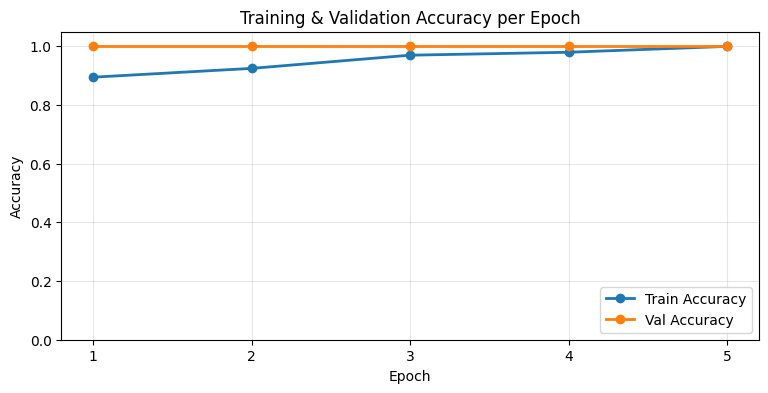

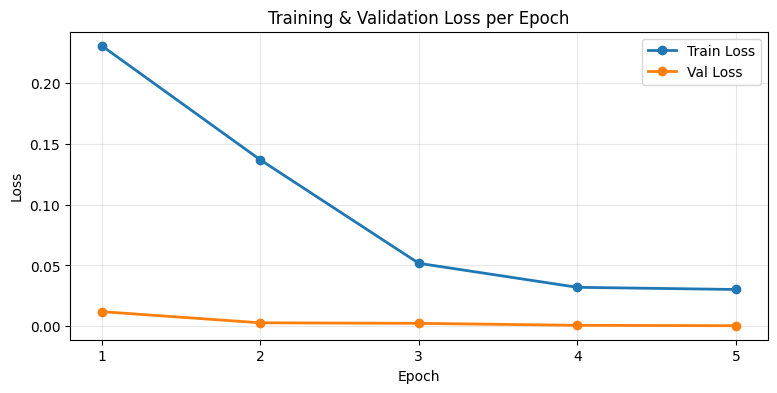

In [14]:
# ==========================================
# SIMPLE STIL-STYLE DEEPFAKE DETECTOR (Colab Ready)
# with Training/Validation accuracy plotting
# ==========================================
!pip install torch torchvision tqdm matplotlib --quiet

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt

# reproducibility (optional)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------
# 1️⃣ Simulated Dataset (fake vs real)
# ------------------------------
class SyntheticDeepfakeDataset(Dataset):
    def __init__(self, n_samples=200, img_size=224, clip_len=4):
        self.n_samples = n_samples
        self.img_size = img_size
        self.clip_len = clip_len
        # note: ToTensor expects HWC uint8/float; we're directly returning tensors below
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size))
        ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        label = random.randint(0, 1)  # 0 = real, 1 = fake
        frames = []
        for _ in range(self.clip_len):
            if label == 0:
                frame = np.ones((self.img_size, self.img_size, 3), np.float32) * random.uniform(0.8, 1.0)
            else:
                frame = np.random.rand(self.img_size, self.img_size, 3).astype(np.float32) * random.uniform(0.5, 1.0)
            # convert to tensor C,H,W
            frames.append(torch.tensor(frame).permute(2, 0, 1))
        clip = torch.stack(frames)  # shape: [clip_len, 3, H, W]
        return clip, torch.tensor(label, dtype=torch.long)

# ------------------------------
# 2️⃣ Simple STIL-like Model (ResNet + Temporal Conv)
# ------------------------------
class SimpleSTIL(nn.Module):
    def __init__(self, num_classes=2, clip_len=4):
        super(SimpleSTIL, self).__init__()
        self.clip_len = clip_len
        base = models.resnet18(weights='IMAGENET1K_V1')
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])  # out: [B*T, 512,1,1]
        self.temporal_conv = nn.Conv1d(512, 128, kernel_size=3, padding=1)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feats = self.feature_extractor(x).view(B, T, 512)   # [B, T, 512]
        feats = feats.permute(0, 2, 1)                      # [B, 512, T]
        temporal = torch.mean(self.temporal_conv(feats), dim=2)  # [B, 128]
        out = self.classifier(temporal)                      # [B, num_classes]
        return out

# ------------------------------
# 3️⃣ Training Utilities
# ------------------------------
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    samples = 0
    for clips, labels in tqdm(loader, desc="Training", leave=False):
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * clips.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        samples += clips.size(0)
    avg_loss = total_loss / samples
    acc = correct / samples
    return avg_loss, acc

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    samples = 0
    with torch.no_grad():
        for clips, labels in loader:
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * clips.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            samples += clips.size(0)
    avg_loss = total_loss / samples
    acc = correct / samples
    return avg_loss, acc

# ------------------------------
# 4️⃣ Main Script (with accuracy tracking & plotting)
# ------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

train_data = SyntheticDeepfakeDataset(n_samples=200)
val_data = SyntheticDeepfakeDataset(n_samples=50)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
val_loader = DataLoader(val_data, batch_size=4)

model = SimpleSTIL().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 5
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_loss_history.append(tr_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(tr_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={tr_acc:.3f}, Val Acc={val_acc:.3f}")

print("\n✅ Training complete — Model ran successfully!")

# ------------------------------
# 5️⃣ Plot Training & Validation Accuracy
# ------------------------------
epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(9,4))
plt.plot(epochs, train_acc_history, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(epochs, val_acc_history, marker='o', linewidth=2, label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy per Epoch')
plt.xticks(epochs)
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()

# (Optional) Plot Loss too
plt.figure(figsize=(9,4))
plt.plot(epochs, train_loss_history, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, val_loss_history, marker='o', linewidth=2, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend(loc='upper right')
plt.show()
